# Coffee Shop Revenue Analysis using Multiple Linear Regression

`Predict Revenue based on time, product category, and business drivers`

## Import Libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load Data

In [87]:
df = pd.read_excel("coffee_shop_dataset.xlsx", engine="openpyxl")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [88]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[us]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location                 str
product_id                   int64
unit_price                 float64
product_category               str
product_type                   str
product_detail                 str
dtype: object

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), object(1), str(4)
memory usage: 12.5+ MB


In [90]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [91]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

## Feature Engineering

In [92]:
df['revenue'] = df['transaction_qty'] * df['unit_price']

df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['hour'] = df['transaction_time'].dt.hour

def time_period(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    else:
        return 'night'

df['time_period'] = df['hour'].apply(time_period)

df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['day_of_week'] = df['transaction_date'].dt.day_name()
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,time_period,day_of_week
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,morning,Sunday
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,morning,Sunday
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,morning,Sunday
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,morning,Sunday
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,morning,Sunday


## Aggregate Data

In [93]:
grouped_df = df.groupby([
    'time_period',
    'product_category',
    'store_location',
    'day_of_week'
]).agg({
    'revenue': 'sum'
}).reset_index()
grouped_df.head()

,time_period,product_category,store_location,day_of_week,revenue
0,afternoon,Bakery,Astoria,Friday,1444.50
1,afternoon,Bakery,Astoria,Monday,1701.00
2,afternoon,Bakery,Astoria,Saturday,1509.25
3,afternoon,Bakery,Astoria,Sunday,1502.50
4,afternoon,Bakery,Astoria,Thursday,1700.25


## Features & Targets

In [94]:
features = [
    'time_period',
    'product_category',
    'store_location',
    'day_of_week'
]

target = 'revenue'

X = pd.get_dummies(grouped_df[features], drop_first=True)
y = grouped_df[target]

In [95]:
X.shape


(558, 18)

## Split Data

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Prediction

In [97]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
y_pred = reg.predict(X_test)

## Evaluation

### $R^2$

In [99]:
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("R2: ", r2)
print("Adjusted R2:", adjusted_r2)

R2:  0.7810559825110095
Adjusted R2: 0.7386797210615275


### Coefficients

In [100]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients.head(20))


                                Feature  Coefficient
3               product_category_Coffee  2886.583977
9                  product_category_Tea  1760.167565
0                   time_period_morning   658.946835
10        store_location_Hell's Kitchen    72.447380
12                   day_of_week_Monday    23.685443
17                day_of_week_Wednesday    16.322217
15                 day_of_week_Thursday    -0.827739
11       store_location_Lower Manhattan   -29.213482
14                   day_of_week_Sunday   -54.622677
16                  day_of_week_Tuesday   -84.059041
13                 day_of_week_Saturday   -84.823061
5   product_category_Drinking Chocolate  -167.772868
4         product_category_Coffee beans  -685.324704
1                     time_period_night -1025.648678
2              product_category_Branded -1031.191667
6             product_category_Flavours -1167.117319
7            product_category_Loose Tea -1173.731738
8   product_category_Packaged Chocolate -1405.

### VIF

In [101]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
# vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X.shape[1])]
# print(vif_data)

vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i) 
    for i in range(X_train.shape[1])
]

print(vif_data)

"""
Low VIF values indicate that the features have little linear correlation with each other 
and do not violate the multicollinearity assumption in linear regression.
"""

                                feature       VIF
0                   time_period_morning  0.012294
1                     time_period_night  0.012702
2              product_category_Branded  0.029957
3               product_category_Coffee  0.029047
4         product_category_Coffee beans  0.035793
5   product_category_Drinking Chocolate  0.031433
6             product_category_Flavours  0.028269
7            product_category_Loose Tea  0.031978
8   product_category_Packaged Chocolate  0.030496
9                  product_category_Tea  0.029688
10        store_location_Hell's Kitchen  0.012292
11       store_location_Lower Manhattan  0.012240
12                   day_of_week_Monday  0.024278
13                 day_of_week_Saturday  0.025563
14                   day_of_week_Sunday  0.026405
15                 day_of_week_Thursday  0.026745
16                  day_of_week_Tuesday  0.025191
17                day_of_week_Wednesday  0.025223


'\nLow VIF values indicate that the features have little linear correlation with each other \nand do not violate the multicollinearity assumption in linear regression.\n'

## Visualization

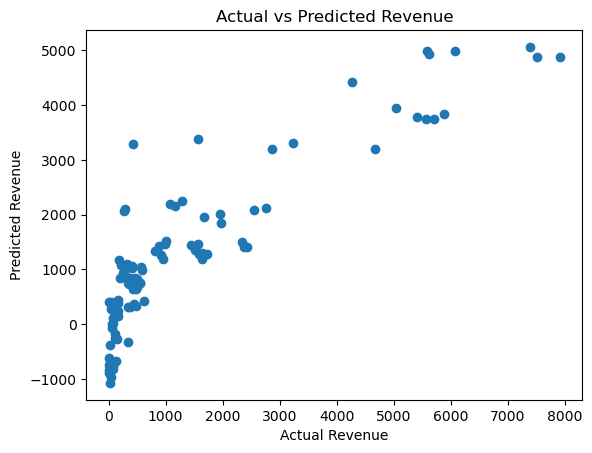

In [102]:
# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()


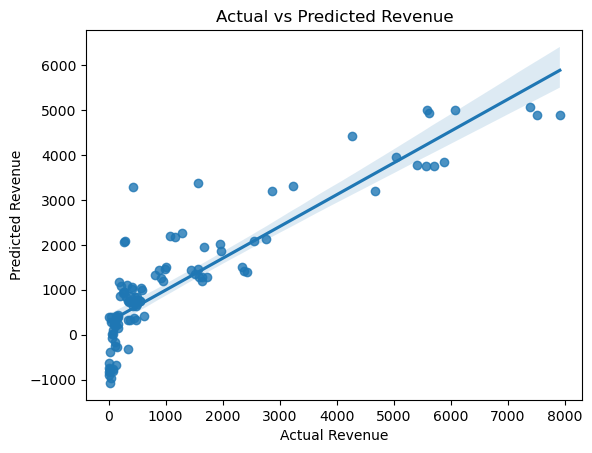

In [103]:
# With Seaborn
plt.figure()

# sns.scatterplot(x=y_test, y=y_pred)
sns.regplot(x=y_test, y=y_pred)

plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')

plt.show()

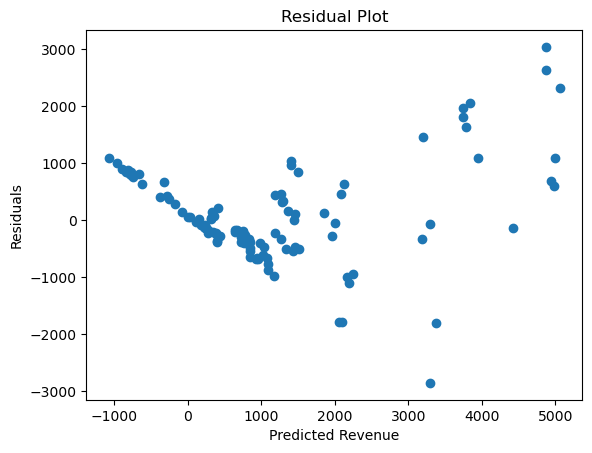

In [104]:
# Residual Plot
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Revenue')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

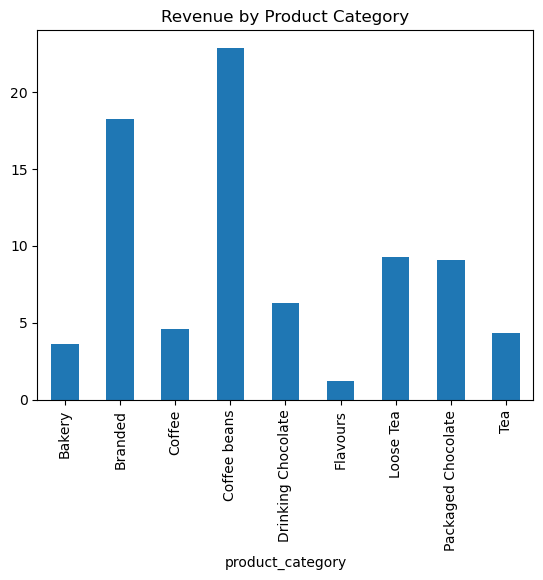

In [105]:
# ==============================
# STEP 14: OPTIONAL EDA VISUALS
# ==============================
# Revenue by product category
df.groupby('product_category')['revenue'].mean().plot(kind='bar')
plt.title('Revenue by Product Category')
plt.show()

# With Log Transformation

In [106]:
# Train-test split
y_test_log = np.log1p(y_test)

In [107]:
log_reg = LinearRegression()

In [108]:
y_train_log = np.log1p(y_train)

log_reg.fit(X_train, y_train_log)

y_pred_log = log_reg.predict(X_test)

In [109]:
y_pred_log_model = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

In [110]:
r2 = r2_score(y_test_actual, y_pred_log_model)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

R2: 0.8648369528840075
Adjusted R2: 0.8386763631196219


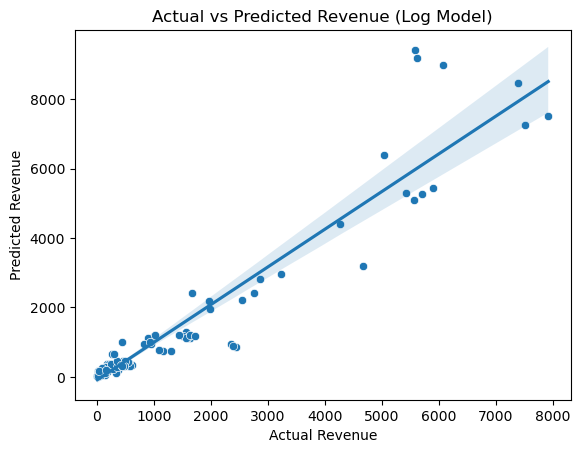

In [111]:
plt.figure()
sns.scatterplot(x=y_test_actual, y=y_pred_log_model)
sns.regplot(x=y_test_actual, y=y_pred_log_model, scatter=False)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue (Log Model)')
plt.show()


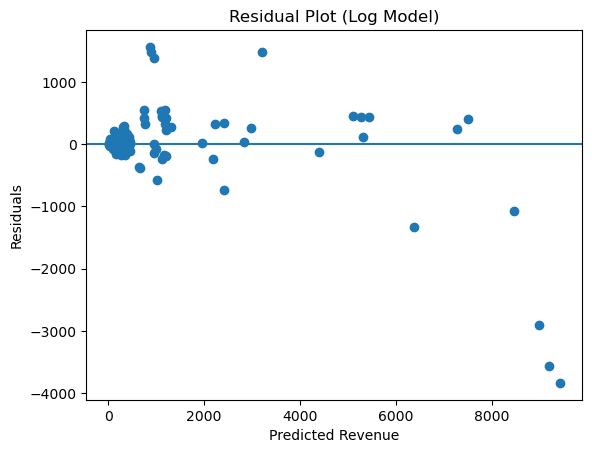

In [112]:
residuals = y_test_actual - y_pred_log_model
plt.figure()
plt.scatter(y_pred_log_model, residuals)
plt.axhline(0)
plt.xlabel('Predicted Revenue')
plt.ylabel('Residuals')
plt.title('Residual Plot (Log Model)')
plt.show()

In [113]:
coefficients_log = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients_log.head(20))

                                Feature  Coefficient
3               product_category_Coffee     1.275342
9                  product_category_Tea     0.921547
0                   time_period_morning     0.726157
17                day_of_week_Wednesday     0.071831
15                 day_of_week_Thursday     0.047718
12                   day_of_week_Monday     0.033069
14                   day_of_week_Sunday     0.022255
16                  day_of_week_Tuesday     0.015210
13                 day_of_week_Saturday    -0.017144
10        store_location_Hell's Kitchen    -0.059230
5   product_category_Drinking Chocolate    -0.074108
11       store_location_Lower Manhattan    -0.193680
4         product_category_Coffee beans    -0.977663
1                     time_period_night    -1.338205
2              product_category_Branded    -1.911378
7            product_category_Loose Tea    -1.971772
6             product_category_Flavours    -2.387523
8   product_category_Packaged Chocolate    -2.